Purpose: To explore the Bhutan basin boundary from the Bhutan NSDI System website.

Install libraries </bt>
- here on the notebook or 
- from terminal within a python virtual environment<br/>

For Notebook option <br/>
 ```
 !pip install --upgrade pip
 !pip install -r requirements.txt
 ``` 
<br/>

For terminal option <br/>
open up a new terminal for instance in a VSCode environment
```
> python -m venv bb_venv <br/>
> bb_venv\Scripts\activate.bat <br/>
(bb_venv)> python -m pip install --upgrade pip  <br/>
(bb_venv)> pip install -r requirements.txt <br/>
```
<br/>


**NOTE:First time run, you need to choose the python environment and it might install ipykernel as well**

In [1]:
!pip install --upgrade pip
!pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


**Import Libraries**

In [2]:
import os
import pandas as pd

import fiona
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt 

import json
import re
from functools import reduce

from pyproj import CRS


arcgis - needs the following libraries installed
- arcgis
- shapely or fiona (I just installed both)
- geopandas
- arcpy
- pyproj
- rtree

NOTE: But for this notebook we aren't using as some features need paid version of ARCGIS.



In [3]:
cwd = os.getcwd()
cwd


'c:\\PS\\Projects\\Omdena\\bhutan_climate_modeling\\code\\basin_border'

##### **Explore Bhutan Basin data**

**Inpect .prj file of Basin boundary, to check the CRS used, if present**

In [4]:
boun_prj_file = "../../data/Basin boundary.prj"

In [5]:
with open(boun_prj_file, "r") as prj_file:
    prj_text = prj_file.read()

In [6]:
# check if prj_text holds the content of 'Bhutan boundary.prj' file
crs = CRS(prj_text)
epsg = crs.to_epsg()
print(f"Name: {crs.name}")
print(f"Coordinate system: {crs.coordinate_system}")
print(f"Area of Use: {crs.area_of_use}")
print(f"EPSG Code (if available): {epsg}")

Name: WGS 84 / Pseudo-Mercator
Coordinate system: cartesian
Area of Use: None
EPSG Code (if available): 3857


**Load the previously downloaded Bhutan - basin boundary data as a .shp file**

In [7]:
boun_shp_file = "../../data/Basin boundary.shp"

In [8]:
def load_basin_data(shp_file="", prj_crs=None):
    gdf_orig = None
    df_gdf_wgs84 = None
    # NOTE: features are the rows from the shp file
    # Refer: https://gis.stackexchange.com/questions/448450/getting-the-number-of-features-in-shapefile-without-opening-it-using-python
    #
    # If we have arcgis account then we can use, similar to below link...
    # Refer: https://gis.stackexchange.com/questions/381120/convert-arcgis-spatially-enabled-dataframe-to-geopandas-geodataframe

    # load shp file
    with fiona.open(shp_file) as features:
        print(f"Total features in basin boundary .shp file: {len(features)}")

        gdf_orig = gpd.GeoDataFrame.from_features(features)
        print(f"Loaded geoDataFrame shape: {gdf_orig.shape}")
        print(f"crs: {gdf_orig.crs}")
    # print(gdf_orig.head(2))

    # Set the correct CRS from the .prj file (Web Mercator)
    gdf_orig.set_crs(epsg=prj_crs, inplace=True)

    # Reproject to WGS84 (EPSG:4326)
    df_gdf_wgs84 = gdf_orig.to_crs("EPSG:4326")

    # Calculate centroids in WGS84
    centroids = df_gdf_wgs84.geometry.centroid

    # Extract longitude and latitude
    df_gdf_wgs84['longitude'] = centroids.x
    df_gdf_wgs84['latitude'] = centroids.y

    # Print the range
    print(f"Longitude range: {df_gdf_wgs84['longitude'].min()} to {df_gdf_wgs84['longitude'].max()}")
    print(f"Latitude range: {df_gdf_wgs84['latitude'].min()} to {df_gdf_wgs84['latitude'].max()}")
    # print(df_gdf_wgs84[['basin', 'longitude', 'latitude']].head())
    return df_gdf_wgs84


In [9]:
# load basin boundary data
gdf_wgs84 = load_basin_data(shp_file=boun_shp_file, prj_crs=epsg)
gdf_wgs84.head(2)

Total features in basin boundary .shp file: 10
Loaded geoDataFrame shape: (10, 7)
crs: None
Longitude range: 88.9878498499434 to 92.03395801646504
Latitude range: 26.945873636088635 to 27.84243536003244


C:\Users\Pankaja\AppData\Local\Temp\ipykernel_28160\13573567.py:26: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df_gdf_wgs84.geometry.centroid


,geometry,basin,path,area_ha,area_sqkm,SHAPE__Len,SHAPE__Are,longitude,latitude
0,"POLYGON ((90.35281 27.22062, 90.35316 27.22078...",Aiechhu,E:\2024-2025\Basin_boundaries\Aiechhu.shp,196390.588555,1963.905886,337019.366034,2.481073e+09,90.464808,26.945874
1,"POLYGON ((92.03864 27.25695, 92.03829 27.25595...",Merak_Sakteng,E:\2024-2025\Basin_boundaries\Merak-Sakteng.shp,13881.067718,138.810677,76767.739616,1.763939e+08,92.033958,27.329946


**Visualize the geoDataFrame**

In [10]:
# just check the crs before visualizing to make sure it is WGS84
gdf_wgs84.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [11]:
def plot_basin_boundaries(gdf=None):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))

    # Plot the basin polygons (not points)
    # gdf.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black', legend=True)
    gdf.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black')

    # Add basin name labels at centroid positions
    for idx, row in gdf.iterrows():
        ax.text(row['longitude'], row['latitude'], row['basin'],
                horizontalalignment='center', verticalalignment='center',
                fontsize=8, color='white', weight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.title("Bhutan Basin Boundary Map (WGS84)", fontsize=10)

    # Set axis limits to the extent of your data
    ax.set_xlim(gdf['longitude'].min()-0.35, gdf['longitude'].max()+0.7)
    ax.set_ylim(gdf['latitude'].min()-0.35, gdf['latitude'].max()+0.85)

    plt.show()



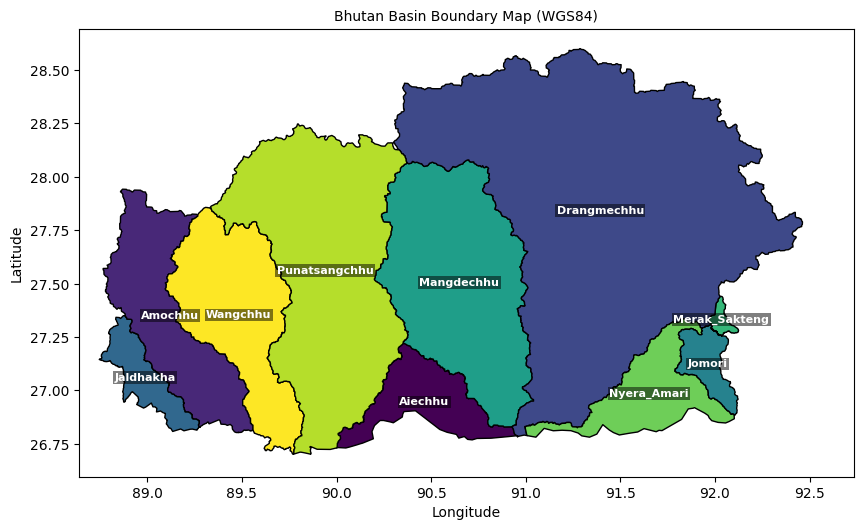

In [12]:
# plot basin-boundaries
plot_basin_boundaries(gdf=gdf_wgs84)


##### **Explore the Discharge distribution**

In [13]:
# load discharge file
d_file = "../../data/Discharge data Major Basin.xlsx"

disc_sheets = pd.ExcelFile(d_file, engine="openpyxl")
disc_sheet_names = list(disc_sheets.sheet_names)
disc_sheet_names


['Lungtenphu (Wangchhu)',
 'Wangdi rapid (Punatshangchhu)',
 'Pangbang dangmechhu',
 'tingtibi (Mangdichhu)',
 'Kurjey (Chamkharchhu)']

**Scripts**

In [14]:
# **************************************************************************
# Below function from Qingfang - repurposed here
# **************************************************************************
def load_station_sheet(xlsx_path: str, sheet_name: str, skiprows: int = 3):
    """
    Load one sheet (station) and do minimal cleaning:
      - Skip metadata rows (default: 3)
      - Trim column names; harmonize 'water Level' -> 'Water Level' if present
      - Parse 'Date' to datetime
      - Coerce 'Flow' and 'Water Level' to numeric
      - Drop entirely-empty columns
      - Sort by 'Date'
    """
    df = pd.read_excel(xlsx_path, sheet_name=sheet_name, skiprows=skiprows)
    df = df.dropna(axis=1, how="all")
    df.columns = [str(c).strip() for c in df.columns]
    if "water Level" in df.columns and "Water Level" not in df.columns:
        df = df.rename(columns={"water Level": "Water Level"})
    if "Date" not in df.columns:
        raise ValueError(f"'Date' column not found in sheet: {sheet_name}")
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    for col in ["Flow", "Water Level"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    keep = [c for c in ["Date", "Flow", "Water Level"] if c in df.columns]
    df = df[keep].dropna(subset=["Date"]).sort_values("Date").reset_index(drop=True)
    return df



In [15]:
# **************************************************************************
#   Pankaja Shankar - functions
# **************************************************************************
# Function to convert deg,mins,secs to decimal Degrees
def dms_to_decimal_degrees(dms_string):
    d_arr = re.split(r'[: ]', dms_string)
    degrees = float(d_arr[0] or "0")
    minutes = float(d_arr[1] or "0")
    seconds = float(d_arr[2] or "0")
    direction = d_arr[3]

    decimal_degrees = degrees + (minutes / 60) + (seconds / 3600)

    # adjust for South or West hemispheres
    if direction == 'S' or direction == 'W':
        decimal_degrees *= -1  

    return decimal_degrees

def extract_worksheet_location_details(file_path="", sheet_name=""):
    # extract information from first 3 rows and the columns
    df_hdr_orig = pd.read_excel(file_path, sheet_name=sheet_name)
    df_hdr = df_hdr_orig[0:3]
    # parse colon_values
    parsed_loc = {
        item.split(' : ')[0].strip(): (
            item.split(' : ')[1].strip()
        )
        for item in df_hdr.columns if "Unnamed" not in item
    }
    # convert the dictionary to a JSON object
    loc = json.loads(json.dumps(parsed_loc, indent=4)) # indent for readable JSON

    # print(loc)
    # next get other details
    loc_coords_arr = [
        cell_value
        for row in df_hdr.itertuples(index=False)
        for cell_value in row
        if isinstance(cell_value, str) and ":" in cell_value
    ]
    # loc_coords
    # parse loc_coords
    parsed_data = {
        item.split(' : ')[0].strip(): (
            dms_to_decimal_degrees(item.split(' : ')[1].strip())  # Process Latitude and Longitude
            if item.split(' : ')[0].strip() in ['Latitude', 'Longitude'] else
            float(item.split(' : ')[1].replace(' metres', '').replace(' sq km', '').strip()) # Process Elevation and Area
        )
        for item in loc_coords_arr
    }

    # convert the dictionary to a JSON object
    loc_coords = json.loads(json.dumps(parsed_data, indent=4)) # indent for readable JSON

    loc_details = {}
    loc_details["Station Name"] = loc["Station Name"]
    loc_details["Latitude"] = loc_coords['Latitude']
    loc_details["Longitude"] = loc_coords['Longitude']
    loc_details["Elevation"] = loc_coords["Elevation"]
    loc_details["Area"] = loc_coords["Area"]
    # print(loc_details)

    return loc_details

def load_worksheet_extract_data_and_combine(file_path="", sheet_name=""):
    step = ""
    df_data = None

    try:        
        step = " extract header details "
        location_details = extract_worksheet_location_details(file_path=file_path, sheet_name=sheet_name)
        step = " extract datarows "
        df_dtls_orig = load_station_sheet(d_file, sheet_name=sheet_name)

        step = " combine details w datarows "
        df_data = df_dtls_orig.copy(deep=True)
        df_data.insert(0, "Station Name", location_details['Station Name'])
        df_data.insert(1, "Latitude", location_details['Latitude'])
        df_data.insert(2, "Longitude", location_details['Longitude'])
        df_data.insert(3, "Elevation", location_details['Elevation'])
        df_data.insert(4, "Area", location_details['Area'])
    except Exception as ex:
        print(f"Error occurred with exception: {ex} at step: {step}")

    return df_data 

def combine_data_from_worksheets(file_path=""):
    df_combined = None
    status = False
    dfs = []
    step = ""

    try:        
        cnt = 0
        step = " extract sheet "
        for sheet_name in disc_sheet_names:
            df = load_worksheet_extract_data_and_combine(file_path=d_file, sheet_name=sheet_name)
            print(f"{sheet_name} data: {df.shape}")
            dfs.append(df)
            cnt += 1
        step = " combine "
        # df_combined = pd.concat(dfs, axis=1)
        df_combined_orig = reduce(lambda l,r: pd.concat([l, r], ignore_index=True), dfs)
        df_combined = df_combined_orig.drop_duplicates().reset_index(drop=True)

        step = " colnames lower "
        df_combined.columns = df_combined.columns.str.lower()
        status = True
    except Exception as ex:
        print(f"Error occurred with exception: {ex} at step: {step}")

    return status, df_combined



**Combine data from worksheets of Discharge spreadsheet**

In [16]:
combine_status, df_discharge = combine_data_from_worksheets(file_path=d_file)
print(f"df_discharge shape: {df_discharge.shape}")
df_discharge.head(4)

Lungtenphu (Wangchhu) data: (12308, 8)
Wangdi rapid (Punatshangchhu) data: (8766, 8)
Pangbang dangmechhu data: (4748, 8)
tingtibi (Mangdichhu) data: (6763, 8)
Kurjey (Chamkharchhu) data: (8766, 8)
df_discharge shape: (41351, 8)


,station name,latitude,longitude,elevation,area,date,flow,water level
0,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-22,5.655,NaN
1,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-23,6.107,0.3450
2,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-24,6.195,0.3525
3,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,2260.0,663.0,1991-04-25,6.404,0.3575


In [17]:
# Pivot the table to find the mean flow for each station
mean_flow_by_station = df_discharge.pivot_table(
    values='flow', 
    index='station name', 
    aggfunc='mean'
).reset_index()

print(mean_flow_by_station)

                                 station name        flow
0          Kurjey on Chamkher Chhu (15490045)   52.351836
1     Lungtenphug on Thimphu Chhu  (12800045)   21.874529
2  PANGBANG ON DANGME CHHU   [ P ] (17120045)  781.430324
3       Tingtibi on Mangdi Chhu (Down Stream)  136.893623
4     Wangdi Rapids on Pho+Mo Chhu (13490045)  298.200705


**Proceed to visualize by superimposing the discharge on the basin regions**

**plotting mean_flow**

In [18]:
from matplotlib.colors import ListedColormap

In [19]:
def plot_combined_basin_and_discharge_mean(gdf_basin=None, df_disch=None, use_color=False):
   
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    # Plot the basin polygons (not points) 
    # gdf_basin.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black', legend=True)
    gdf_basin.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black')

    # Add basin name labels at centroid positions
    for idx, row in gdf_basin.iterrows():
        ax.text(row['longitude'], row['latitude'], row['basin'],
                horizontalalignment='center', verticalalignment='center', 
                fontsize=8, color='white', weight='bold', rotation=-30,
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    
    # METHOD 2:
    mean_flow_df = pd.pivot_table(df_disch, values='flow', index=['station name', 'latitude', 'longitude'], aggfunc='mean').reset_index()
    mean_flow_df.rename(columns={'flow': 'mean_flow'}, inplace=True)

    # Convert the mean flow DataFrame to a GeoDataFrame
    gdf_points = gpd.GeoDataFrame(
        mean_flow_df,
        geometry=gpd.points_from_xy(mean_flow_df['longitude'], mean_flow_df['latitude']),
        crs=gdf_basin.crs
    )
    # Plot the scatter points on top of the basin
    if use_color:
        # Define your custom colors (can be color names or hex codes)
        custom_colors = ['blue', 'green', 'red', '#FFD700', 'violet'] # Example: blue, green, red, gold

        # Create the ListedColormap
        custom_cmap = ListedColormap(custom_colors)
        print("Printing colored - TBD")
        scatter = gdf_points.plot(
            ax=ax,
            marker='o',
            # color='red',
            # cmap="viridis",
            column="mean_flow",
            cmap=custom_cmap,   # 'Blues',
            markersize=gdf_points['mean_flow']/5,  # Scale marker size by mean flow
            label='Mean Flow Stations'
        )
    else:
        scatter = gdf_points.plot(
            ax=ax,
            marker='o',
            color='red',
            markersize=gdf_points['mean_flow']/5,  # Scale marker size by mean flow
            label='Mean Flow Stations'
        )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    # plt.tight_layout()
    plt.title("Bhutan Basin Boundary - Discharge Points Within Basins", fontsize=10)
    plt.show()


Plot style 1 - WITHOUT LABELING mean_flow


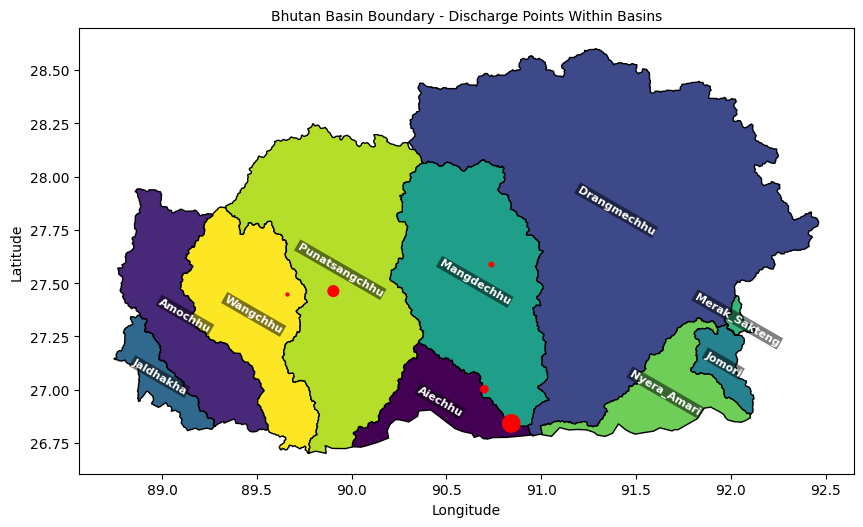

In [20]:
# plot the mean flow by discharge station
print("Plot style 1 - WITHOUT LABELING mean_flow")
plot_combined_basin_and_discharge_mean(gdf_basin=gdf_wgs84, df_disch=df_discharge)


Plot style 1 - WITHOUT LABELING mean_flow - with different colors
Printing colored - TBD


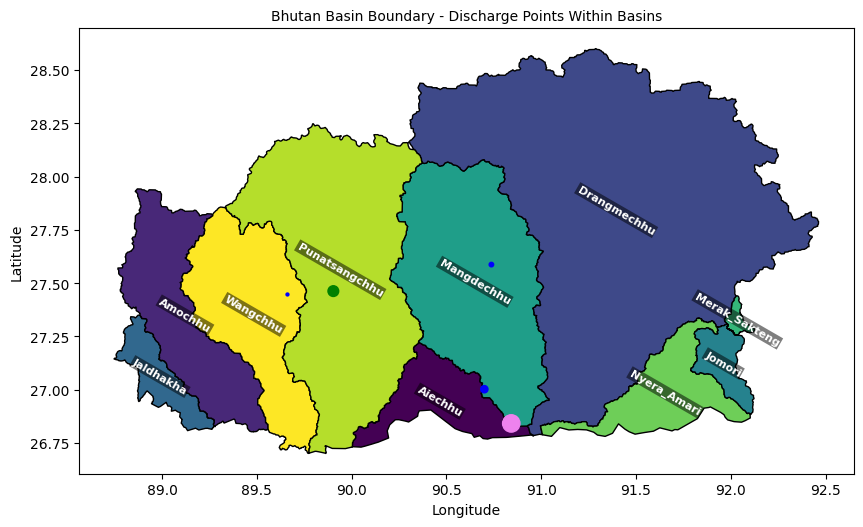

In [21]:
# plot the mean flow by discharge station with different colors
print("Plot style 1 - WITHOUT LABELING mean_flow - with different colors")
plot_combined_basin_and_discharge_mean(gdf_basin=gdf_wgs84, df_disch=df_discharge, use_color=True)

**Plotting mean_flow, along with discharge station labeling**

In [22]:
from adjustText import adjust_text

In [23]:
def plot_combined_basin_and_discharge_mean2(gdf_basin=None, df_disch=None):
        
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    # Plot the basin polygons (not points) 
    # gdf_basin.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black', legend=True)
    gdf_basin.plot(ax=ax, column='basin', cmap='viridis', edgecolor='black')

    # Add basin name labels at centroid positions
    for idx, row in gdf_basin.iterrows():
        ax.text(row['longitude'], row['latitude'], row['basin'],
                horizontalalignment='center', verticalalignment='center', 
                fontsize=8, color='white', weight='bold', # rotation=-30,
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    

    # METHOD 2:
    mean_flow_df = pd.pivot_table(df_disch, values='flow', index=['station name', 'latitude', 'longitude'], aggfunc='mean').reset_index()
    mean_flow_df.rename(columns={'flow': 'mean_flow'}, inplace=True)
    
    # Convert the mean flow DataFrame to a GeoDataFrame
    gdf_points = gpd.GeoDataFrame(
        mean_flow_df,
        geometry=gpd.points_from_xy(mean_flow_df['longitude'], mean_flow_df['latitude']),
        crs=gdf_basin.crs
    )
    # Plot the scatter points on top of the basin
    scatter = gdf_points.plot(
        ax=ax,
        marker='o',
        color='red',
        markersize=gdf_points['mean_flow']/6,  # Scale marker size by mean flow
        label='Mean Flow Stations'
    )

    texts = []
    for x, y, label in zip(gdf_points.geometry.x, gdf_points.geometry.y, gdf_points['station name']):
        sm_label = label[0:10]
        texts.append(ax.text(x, y, sm_label, ha='center', va='top', fontsize=8,
                             color='white', rotation=15,
                             bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1)
                             ))  # weight='bold',

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='red', lw=0.5))
    
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    # plt.tight_layout()
    plt.title("Bhutan Basin Boundary - Discharge Points Within Basins", fontsize=10)
    plt.show()

    return mean_flow_df

Plot style 1 - WITH LABELING mean_flow


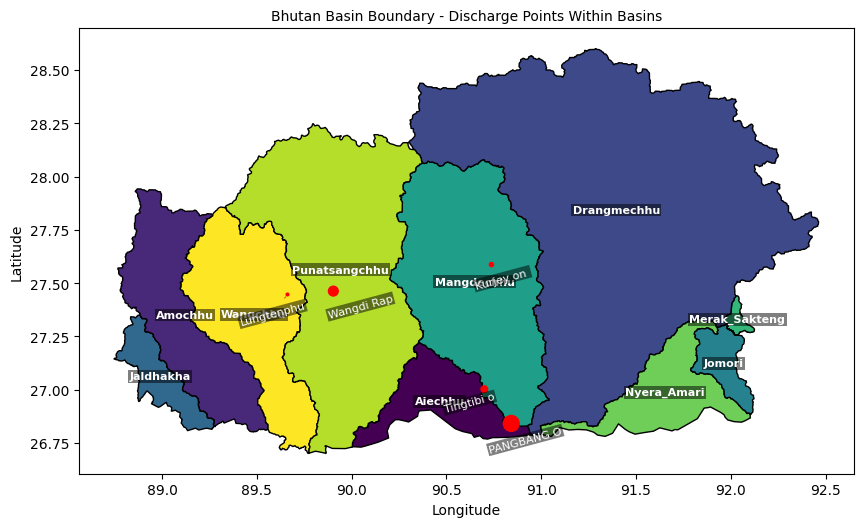

In [24]:
# plot the mean flow by discharge station
print("Plot style 1 - WITH LABELING mean_flow")
df_mean = plot_combined_basin_and_discharge_mean2(gdf_basin=gdf_wgs84, df_disch=df_discharge)

In [25]:
df_mean

,station name,latitude,longitude,mean_flow
0,Kurjey on Chamkher Chhu (15490045),27.586944,90.736944,52.351836
1,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,21.874529
2,PANGBANG ON DANGME CHHU [ P ] (17120045),26.841667,90.841667,781.430324
3,Tingtibi on Mangdi Chhu (Down Stream),27.002222,90.699722,136.893623
4,Wangdi Rapids on Pho+Mo Chhu (13490045),27.462500,89.903056,298.200705


##### **Explore towards final output**

**Output version - final_output_v1**

In [26]:
# mean flow
mean_flow_df1 = pd.pivot_table(df_discharge, values='flow', index=['station name', 'latitude', 'longitude'], aggfunc='mean').reset_index()
mean_flow_df1.rename(columns={'flow': 'mean_flow'}, inplace=True)

In [27]:
mean_flow_df1

,station name,latitude,longitude,mean_flow
0,Kurjey on Chamkher Chhu (15490045),27.586944,90.736944,52.351836
1,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,21.874529
2,PANGBANG ON DANGME CHHU [ P ] (17120045),26.841667,90.841667,781.430324
3,Tingtibi on Mangdi Chhu (Down Stream),27.002222,90.699722,136.893623
4,Wangdi Rapids on Pho+Mo Chhu (13490045),27.462500,89.903056,298.200705


In [28]:
# massage mean flow with the points appended to it
points = [Point(row["longitude"], row["latitude"]) for idx, row in mean_flow_df1.iterrows()]
mean_flow_df1['point'] = points
mean_flow_df1

,station name,latitude,longitude,mean_flow,point
0,Kurjey on Chamkher Chhu (15490045),27.586944,90.736944,52.351836,POINT (90.73694444444445 27.586944444444445)
1,Lungtenphug on Thimphu Chhu (12800045),27.446667,89.661111,21.874529,POINT (89.66111111111111 27.446666666666665)
2,PANGBANG ON DANGME CHHU [ P ] (17120045),26.841667,90.841667,781.430324,POINT (90.84166666666667 26.841666666666665)
3,Tingtibi on Mangdi Chhu (Down Stream),27.002222,90.699722,136.893623,POINT (90.69972222222222 27.002222222222223)
4,Wangdi Rapids on Pho+Mo Chhu (13490045),27.462500,89.903056,298.200705,POINT (89.90305555555557 27.4625)


In [29]:
# find valid points by do an sjoin
df_valid2 = gdf_wgs84.sjoin(gpd.GeoDataFrame(mean_flow_df1,
    geometry=gpd.points_from_xy(mean_flow_df1["longitude"], mean_flow_df1["latitude"]), crs="epsg:4326"
), how="left").assign(
    discharge_tag=lambda d: (~d["index_right"].isna()).astype(int)
)

In [30]:
df_valid2['basin']

0          Aiechhu
1    Merak_Sakteng
2       Mangdechhu
2       Mangdechhu
2       Mangdechhu
3        Jaldhakha
4          Amochhu
5         Wangchhu
6      Drangmechhu
7    Punatsangchhu
8      Nyera_Amari
9           Jomori
Name: basin, dtype: object

In [31]:
gdf_wgs84['basin']

0          Aiechhu
1    Merak_Sakteng
2       Mangdechhu
3        Jaldhakha
4          Amochhu
5         Wangchhu
6      Drangmechhu
7    Punatsangchhu
8      Nyera_Amari
9           Jomori
Name: basin, dtype: object

In [32]:
# rearrange columns
cols = ['basin','station name','longitude_left', 'latitude_left', 'discharge_tag', 'index_right', 'longitude_right', 'latitude_right']
df_rearranged = df_valid2[cols + [c for c in df_valid2.columns if c not in cols]]
print(f"Final basin-discharge data shape: {df_rearranged.shape}")
df_rearranged

Final basin-discharge data shape: (12, 16)


,basin,station name,longitude_left,latitude_left,discharge_tag,index_right,longitude_right,latitude_right,geometry,path,area_ha,area_sqkm,SHAPE__Len,SHAPE__Are,mean_flow,point
0,Aiechhu,NaN,90.464808,26.945874,0,NaN,NaN,NaN,"POLYGON ((90.35281 27.22062, 90.35316 27.22078...",E:\2024-2025\Basin_boundaries\Aiechhu.shp,1.963906e+05,1963.905886,3.370194e+05,2.481073e+09,NaN,NaN
1,Merak_Sakteng,NaN,92.033958,27.329946,0,NaN,NaN,NaN,"POLYGON ((92.03864 27.25695, 92.03829 27.25595...",E:\2024-2025\Basin_boundaries\Merak-Sakteng.shp,1.388107e+04,138.810677,7.676774e+04,1.763939e+08,NaN,NaN
2,Mangdechhu,PANGBANG ON DANGME CHHU [ P ] (17120045),90.649025,27.506149,1,2.0,90.841667,26.841667,"POLYGON ((90.77251 27.94007, 90.7727 27.93836,...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,7.436605e+05,7436.605311,5.247929e+05,9.488740e+09,781.430324,POINT (90.84166666666667 26.841666666666665)
2,Mangdechhu,Tingtibi on Mangdi Chhu (Down Stream),90.649025,27.506149,1,3.0,90.699722,27.002222,"POLYGON ((90.77251 27.94007, 90.7727 27.93836,...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,7.436605e+05,7436.605311,5.247929e+05,9.488740e+09,136.893623,POINT (90.69972222222222 27.002222222222223)
2,Mangdechhu,Kurjey on Chamkher Chhu (15490045),90.649025,27.506149,1,0.0,90.736944,27.586944,"POLYGON ((90.77251 27.94007, 90.7727 27.93836,...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,7.436605e+05,7436.605311,5.247929e+05,9.488740e+09,52.351836,POINT (90.73694444444445 27.586944444444445)
3,Jaldhakha,NaN,88.987850,27.061616,0,NaN,NaN,NaN,"POLYGON ((88.94369 26.93431, 88.94641 26.93632...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,1.038943e+05,1038.942931,2.520154e+05,1.314962e+09,NaN,NaN
4,Amochhu,NaN,89.120110,27.350269,0,NaN,NaN,NaN,"POLYGON ((89.30275 26.84244, 89.30086 26.84241...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,3.929619e+05,3929.619367,4.884296e+05,4.999591e+09,NaN,NaN
5,Wangchhu,Lungtenphug on Thimphu Chhu (12800045),89.482723,27.353115,1,1.0,89.661111,27.446667,"POLYGON ((89.50362 27.78028, 89.50472 27.77953...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,4.608337e+05,4608.336971,4.806525e+05,5.864101e+09,21.874529,POINT (89.66111111111111 27.446666666666665)
6,Drangmechhu,NaN,91.395029,27.842435,0,NaN,NaN,NaN,"POLYGON ((90.9564 26.78792, 90.95298 26.78764,...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,2.109827e+06,21098.266822,1.062589e+06,2.707480e+10,NaN,NaN
7,Punatsangchhu,Wangdi Rapids on Pho+Mo Chhu (13490045),89.939466,27.562875,1,4.0,89.903056,27.462500,"POLYGON ((89.78471 26.70481, 89.77852 26.70302...",E:\2024-2025\Basin_boundaries\Tb_basins.shp,9.765747e+05,9765.747380,7.053781e+05,1.247491e+10,298.200705,POINT (89.90305555555557 27.4625)


In [33]:
df_rearranged.columns

Index(['basin', 'station name', 'longitude_left', 'latitude_left',
       'discharge_tag', 'index_right', 'longitude_right', 'latitude_right',
       'geometry', 'path', 'area_ha', 'area_sqkm', 'SHAPE__Len', 'SHAPE__Are',
       'mean_flow', 'point'],
      dtype='object')

In [34]:
df_rearranged['basin']

0          Aiechhu
1    Merak_Sakteng
2       Mangdechhu
2       Mangdechhu
2       Mangdechhu
3        Jaldhakha
4          Amochhu
5         Wangchhu
6      Drangmechhu
7    Punatsangchhu
8      Nyera_Amari
9           Jomori
Name: basin, dtype: object

In [35]:
df_rearranged.shape

(12, 16)

In [36]:
type(df_rearranged)

geopandas.geodataframe.GeoDataFrame

**Select few columns for now, we can improve upon as per the need**

In [37]:
sel_cols = ['discharge_tag', 'station name', 'longitude_left', 'latitude_left', 'longitude_right', 'latitude_right']
grouped_data = df_rearranged.groupby('basin')[sel_cols].sum()
grouped_data


,discharge_tag,station name,longitude_left,latitude_left,longitude_right,latitude_right
basin,,,,,,
Aiechhu,0,0,90.464808,26.945874,0.000000,0.000000
Amochhu,0,0,89.120110,27.350269,0.000000,0.000000
Drangmechhu,0,0,91.395029,27.842435,0.000000,0.000000
Jaldhakha,0,0,88.987850,27.061616,0.000000,0.000000
Jomori,0,0,91.959758,27.123484,0.000000,0.000000
Mangdechhu,3,PANGBANG ON DANGME CHHU [ P ] (17120045)Ting...,271.947075,82.518446,272.278333,81.430833
Merak_Sakteng,0,0,92.033958,27.329946,0.000000,0.000000
Nyera_Amari,0,0,91.652809,26.987295,0.000000,0.000000
Punatsangchhu,1,Wangdi Rapids on Pho+Mo Chhu (13490045),89.939466,27.562875,89.903056,27.462500


In [38]:
final_output_v1 = grouped_data.reset_index()
final_output_v1

,basin,discharge_tag,station name,longitude_left,latitude_left,longitude_right,latitude_right
0,Aiechhu,0,0,90.464808,26.945874,0.000000,0.000000
1,Amochhu,0,0,89.120110,27.350269,0.000000,0.000000
2,Drangmechhu,0,0,91.395029,27.842435,0.000000,0.000000
3,Jaldhakha,0,0,88.987850,27.061616,0.000000,0.000000
4,Jomori,0,0,91.959758,27.123484,0.000000,0.000000
5,Mangdechhu,3,PANGBANG ON DANGME CHHU [ P ] (17120045)Ting...,271.947075,82.518446,272.278333,81.430833
6,Merak_Sakteng,0,0,92.033958,27.329946,0.000000,0.000000
7,Nyera_Amari,0,0,91.652809,26.987295,0.000000,0.000000
8,Punatsangchhu,1,Wangdi Rapids on Pho+Mo Chhu (13490045),89.939466,27.562875,89.903056,27.462500
9,Wangchhu,1,Lungtenphug on Thimphu Chhu (12800045),89.482723,27.353115,89.661111,27.446667


**Save results in the ../../data folder**

In [39]:
# save final_output_v1 for now in the data folder itself
def save_file(df, file_path="", version=""):
    save_file = f"{file_path}_{version}.csv"
    df.to_csv(save_file, index=None)

In [40]:
results_file = "../../data/saved_basin_discharge_results"
version = "v1"
save_file(final_output_v1, file_path=results_file, version=version)